# Data Loading, Storage, and File Formats

## Reading and Writing Data in Text Format
### Pandas menyediakan berbagai fungsi untuk membaca data tabular sebagai dataframe. Salah satu yang sering digunakan adalah read_csv
#### berikut fungsi pembacaan file lengkapnya:
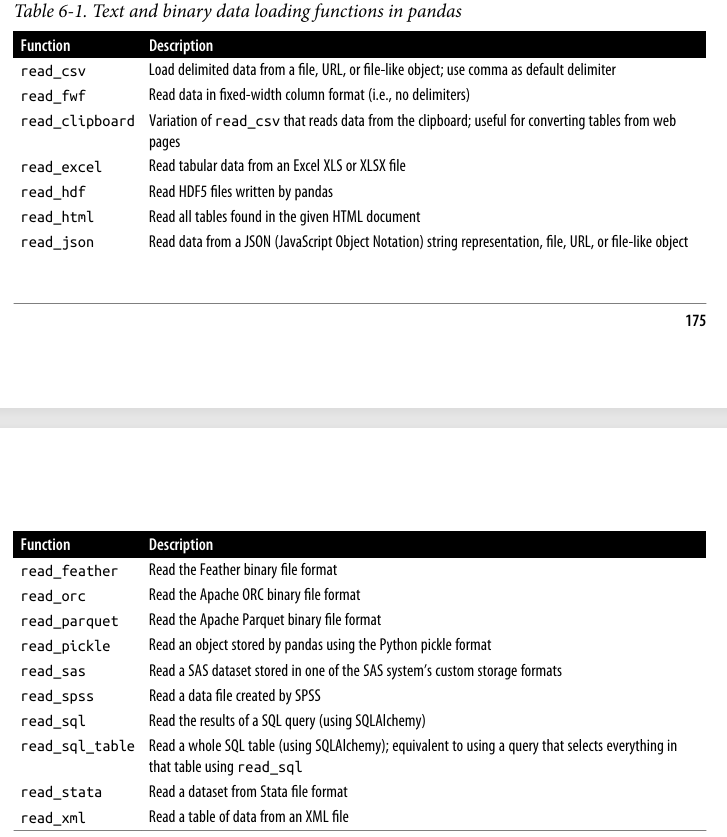

### mereka juga memiliki beberapa argumen opsional yang masuk kategori berikut:
#### 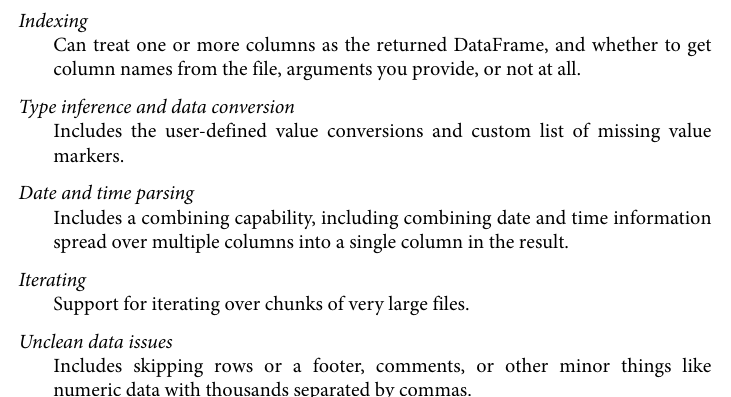

In [4]:
# Mari kita coba pada file .csv sederhana
import numpy as np
import pandas as pd

!type examples\ex1.csv

a,b,c,d,message
1,2,3,4,hello
5,6,7,8,world
9,10,11,12,foo


In [ ]:
df = pd.read_csv('examples/ex1.csv')
print(df) # menghasilkan dataframe dengan kolom sesuai baris paling atas .csv

   a   b   c   d message
0  1   2   3   4   hello
1  5   6   7   8   world
2  9  10  11  12     foo


In [6]:
# beberapa file tidak memiliki baris header
!type examples\ex2.csv

1,2,3,4,hello
5,6,7,8,world
9,10,11,12,foo


In [11]:
# kita harus menambahkan argumen header=None
df1 = pd.read_csv('examples/ex2.csv', header=None)
print(df1) # menghasilkan dataframe dengan kolom bernama 0,1,2,3,4 sesuai jumlah kolom pada file .csv

# atau kita bisa menspesifikasikan nama kolomnya sendiri dengan menambahkan argumen names=[...]
print("\n")
df2 = pd.read_csv('examples/ex2.csv', names=["a", "b", "c", "d", "message"])
print(df2) # menghasilkan dataframe dengan kolom sesuai nama yang kita spesifikasikan

# bila ingin mengubah kolom menjadi index, kita bisa menambahkan argumen index_col=...
print("\n")
df3 = pd.read_csv('examples/ex2.csv', names=["a", "b", "c", "d", "message"], index_col="message")
print(df3) # menghasilkan dataframe dengan kolom sesuai nama yang kita spesifikasikan dan kolom message menjadi index

   0   1   2   3      4
0  1   2   3   4  hello
1  5   6   7   8  world
2  9  10  11  12    foo


   a   b   c   d message
0  1   2   3   4   hello
1  5   6   7   8   world
2  9  10  11  12     foo


         a   b   c   d
message               
hello    1   2   3   4
world    5   6   7   8
foo      9  10  11  12


In [ ]:
# beberapa data misal tidak memiliki pembatas yang jelas
# di file ini, pembatas bukan comma, tapi spasi
!type examples\ex3.csv

            A         B         C
aaa -0.264438 -1.026059 -0.619500
bbb  0.927272  0.302904 -0.032399
ccc -0.264273 -0.386314 -0.217601
ddd -0.871858 -0.348382  1.100491


In [15]:
# maka kita gunakan argumen sep='\s+' agar file bisa dibaca dengan benar
df4 = pd.read_csv('examples/ex3.csv', sep="\\s+") #s+ menandakan satu atau lebih spasi
print(df4) # menghasilkan dataframe dengan kolom sesuai baris paling atas .csv

            A         B         C
aaa -0.264438 -1.026059 -0.619500
bbb  0.927272  0.302904 -0.032399
ccc -0.264273 -0.386314 -0.217601
ddd -0.871858 -0.348382  1.100491


In [16]:
# misal ada data yang rownya perlu di skip
!type examples\ex4.csv

# hey!
a,b,c,d,message
# just wanted to make things more difficult for you
# who reads CSV files with computers, anyway?
1,2,3,4,hello
5,6,7,8,world
9,10,11,12,foo


In [17]:
# kita bisa menggunakan argumen skiprows=... untuk melewati baris tertentu
df5 = pd.read_csv('examples/ex4.csv', skiprows=[0, 2, 3]) # melewati baris 0,2,3
print(df5) # menghasilkan dataframe dengan kolom sesuai baris paling atas .csv dan melewati baris 0,2,3

   a   b   c   d message
0  1   2   3   4   hello
1  5   6   7   8   world
2  9  10  11  12     foo


In [18]:
# beberapa data memiliki missing value
!type examples\ex5.csv

something,a,b,c,d,message
one,1,2,3,4,NA
two,5,6,,8,world
three,9,10,11,12,foo


In [24]:
# bila kita hanya membaca biasa
df6 = pd.read_csv('examples/ex5.csv')
print(df6) # menghasilkan dataframe dengan kolom sesuai baris paling atas .csv dan missing value akan diisi NaN

# salah satu handling missing value adalah dengan menambahkan argumen na_values=...
df7 = pd.read_csv('examples/ex5.csv', na_values=['NULL'])
print(f"\n{df7}") # menghasilkan dataframe dengan kolom sesuai baris paling atas .csv dan missing value yang bernilai 'NULL' akan diisi NaN
# atau dengan keep_default_na= false, maka semua missing value akan diisi NaN
df8= pd.read_csv('examples/ex5.csv', keep_default_na=False)
print(f"\n{df8}") # menghasilkan dataframe dengan kolom sesuai baris paling atas .csv dan semua missing value akan diisi NaN

  something  a   b     c   d message
0       one  1   2   3.0   4     NaN
1       two  5   6   NaN   8   world
2     three  9  10  11.0  12     foo

  something  a   b     c   d message
0       one  1   2   3.0   4     NaN
1       two  5   6   NaN   8   world
2     three  9  10  11.0  12     foo

  something  a   b   c   d message
0       one  1   2   3   4      NA
1       two  5   6       8   world
2     three  9  10  11  12     foo


#### berikut argumen yang sering digunakan untuk membaca file csv:
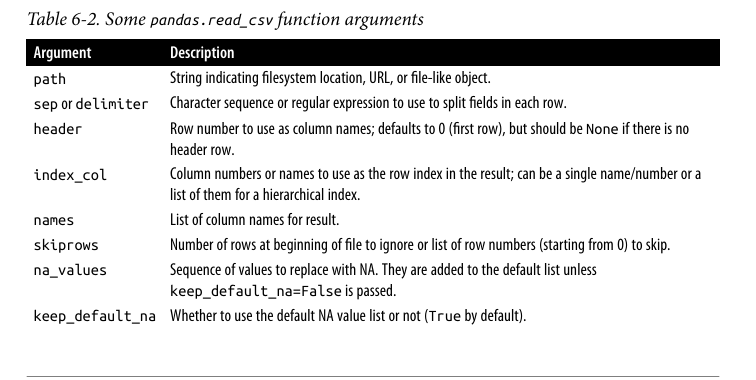
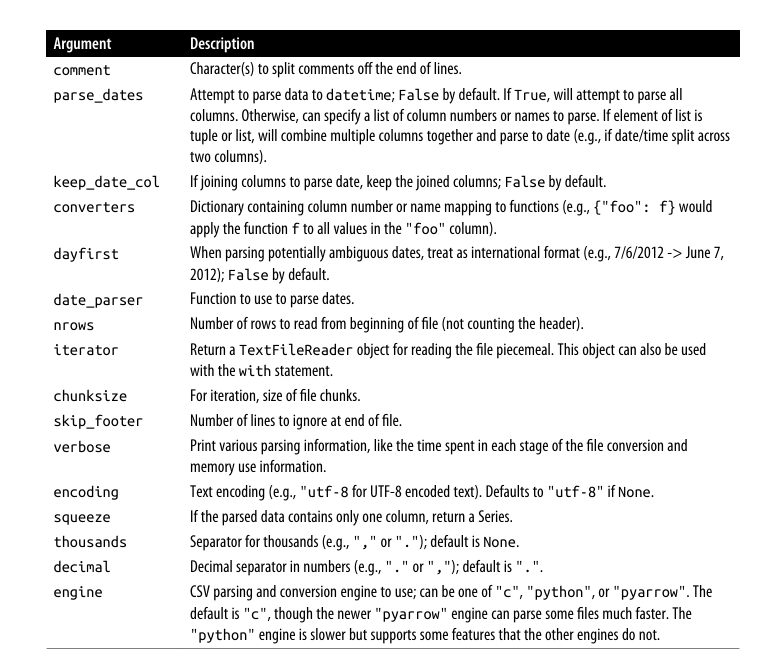

### Reading Text Files in Pieces
#### data sering disajikan dalam file text yang sangat besar, jadi kita perlu skill membaca dalam bagian-bagian kecil.

In [ ]:
# kita bisa meminta panda menampilkan data dalam potongan baris dengan max-rows=... dan nrows=...
pd.options.display.max_rows = 10
result = pd.read_csv('examples/ex6.csv')
print(result) # menampilkan 10 baris pertama dan terakhir dari dataframe

           one       two     three      four key
0     0.467976 -0.038649 -0.295344 -1.824726   L
1    -0.358893  1.404453  0.704965 -0.200638   B
2    -0.501840  0.659254 -0.421691 -0.057688   G
3     0.204886  1.074134  1.388361 -0.982404   R
4     0.354628 -0.133116  0.283763 -0.837063   Q
...        ...       ...       ...       ...  ..
9995  2.311896 -0.417070 -1.409599 -0.515821   L
9996 -0.479893 -0.650419  0.745152 -0.646038   E
9997  0.523331  0.787112  0.486066  1.093156   K
9998 -0.362559  0.598894 -1.843201  0.887292   G
9999 -0.096376 -1.012999 -0.657431 -0.573315   0

[10000 rows x 5 columns]


In [27]:
# atau dengan menambahkan argumen nrows=... untuk menampilkan sejumlah baris tertentu
pd.read_csv('examples/ex6.csv', nrows=10) # menampilkan 10 baris pertama dari dataframe

,one,two,three,four,key
0,0.467976,-0.038649,-0.295344,-1.824726,L
1,-0.358893,1.404453,0.704965,-0.200638,B
2,-0.501840,0.659254,-0.421691,-0.057688,G
3,0.204886,1.074134,1.388361,-0.982404,R
4,0.354628,-0.133116,0.283763,-0.837063,Q
5,1.817480,0.742273,0.419395,-2.251035,Q
6,-0.776764,0.935518,-0.332872,-1.875641,U
7,-0.913135,1.530624,-0.572657,0.477252,K
8,0.358480,-0.497572,-0.367016,0.507702,S
9,-1.740877,-1.160417,-1.637830,2.172201,G


In [ ]:
# ada argumen chunksize=... yang bisa digunakan untuk membaca file dalam potongan tertentu
chunker = pd.read_csv('examples/ex6.csv', chunksize=1000) # membaca file dalam potongan 1000 baris
type(chunker) # akan menghasilkan <class 'pandas.io.parsers.TextFileReader'>, yang bisa diiterasi untuk mendapatkan potongan data dengan get_chunk()

pandas.io.parsers.readers.TextFileReader

### Writing Data to Text Format
#### proses ini kebalikan dari proses membaca data, kita bisa menggunakan to_csv() untuk menulis dataframe ke file .csv

In [ ]:
# misal kita pakai data ex5.csv yang memiliki missing value
data = pd.read_csv('examples/ex5.csv')
print(data) # menampilkan dataframe dengan missing value yang diisi NaN
# misal kita ingin dalam csv
import sys
data.to_csv('examples/out.csv') # menulis dataframe ke file .csv
# argumen sep bisa digunakan untuk menentukan pembatas kolom
# untuk mrnghilangkan index dan header, kita bisa menambahkan argumen index=False dan header=False
#untuk menamai kolom, kita bisa menambahkan argumen columns=[...]

  something  a   b     c   d message
0       one  1   2   3.0   4     NaN
1       two  5   6   NaN   8   world
2     three  9  10  11.0  12     foo


In [36]:
# yang berbeda adalah handling missing value, disini kita menggunakan na_rep=
data.to_csv(sys.stdout, na_rep='NULL') # menulis dataframe ke stdout dengan missing value diisi 'NULL'

,something,a,b,c,d,message
0,one,1,2,3.0,4,NULL
1,two,5,6,NULL,8,world
2,three,9,10,11.0,12,foo


### JSON Data
#### JSON(JavaScript Object Notation) struktur data fleksibel yang bentuknya mirip dictionary di Python. Pandas memiliki fungsi read_json() dan to_json() untuk membaca dan menulis data JSON.

In [37]:
obj = """
{"name": "Wes",
 "cities_lived": ["Akron", "Nashville", "New York", "San Francisco"],
 "pet": null,
 "siblings": [{"name": "Scott", "age": 34, "hobbies": ["guitars", "soccer"]},
              {"name": "Katie", "age": 42, "hobbies": ["diving", "art"]}]
}
"""
import json
result = json.loads(obj) # mengkonversi string JSON menjadi bentuk Python
print(result) # menampilkan dictionary Python hasil konversi dari string JSON

{'name': 'Wes', 'cities_lived': ['Akron', 'Nashville', 'New York', 'San Francisco'], 'pet': None, 'siblings': [{'name': 'Scott', 'age': 34, 'hobbies': ['guitars', 'soccer']}, {'name': 'Katie', 'age': 42, 'hobbies': ['diving', 'art']}]}


In [38]:
# json.dumps() bisa digunakan untuk mengkonversi bentuk Python menjadi string JSON
asjson = json.dumps(result) # mengkonversi dictionary Python menjadi string JSON
print(asjson) # menampilkan string JSON hasil konversi dari dictionary Python

{"name": "Wes", "cities_lived": ["Akron", "Nashville", "New York", "San Francisco"], "pet": null, "siblings": [{"name": "Scott", "age": 34, "hobbies": ["guitars", "soccer"]}, {"name": "Katie", "age": 42, "hobbies": ["diving", "art"]}]}


In [39]:
# kita bisa memberi json dalam bentuk list of dictionaries menjadi dataframe
siblings = pd.DataFrame(result['siblings'], columns=['name', 'age'])
print(siblings) # menampilkan dataframe dengan kolom name dan age dari list of dictionaries pada key siblings

    name  age
0  Scott   34
1  Katie   42


In [40]:
# dengan pandas read_json() dan to_json() kita bisa membaca dan menulis data JSON
!type examples\example.json

[{"a": 1, "b": 2, "c": 3},
 {"a": 4, "b": 5, "c": 6},
 {"a": 7, "b": 8, "c": 9}]


In [ ]:
data = pd.read_json('examples/example.json') # defaultnya, tiap object json menjadi baris
print(data) # menampilkan dataframe dari file .json

   a  b  c
0  1  2  3
1  4  5  6
2  7  8  9


## Binary Data Formats

### Reading Microsoft Excel Files
#### kita bisa membaca file xls atau xlsx dengan class pandas.ExcelFile() dan fungsi read_excel()

In [ ]:
# dengan pd.ExcelFile() akan secara otomatis membaca semua sheet pada file excel, dan kita bisa memilih sheet tertentu dengan argumen sheet_name=...
# class ini digunakan untuk membaca file excel dengan banyak sheet, sehingga kita bisa memilih sheet tertentu untuk dibaca
xlsx = pd.ExcelFile('examples/ex1.xlsx')
print(xlsx.sheet_names) # menampilkan semua sheet pada file excel

['Sheet1']


In [49]:
# untuk membaca, kita gunakan parse dengan argumen sheet_name=...
xlsx.parse(sheet_name='Sheet1') # menampilkan dataframe dari sheet1 pada file excel

,Unnamed: 0,a,b,c,d,message
0,0,1,2,3,4,hello
1,1,5,6,7,8,world
2,2,9,10,11,12,foo


In [50]:
# tabel excel memiliki index dan header, kita bisa menambahkan argumen index_col=... dan header=...
xlsx.parse(sheet_name='Sheet1', index_col=0, header=0) # menampilkan dataframe dari sheet1 pada file excel dengan kolom pertama sebagai index dan baris pertama sebagai header

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


In [51]:
# bila menggunakan read_excel(), kita bisa langsung membaca sheet tertentu dengan argumen sheet_name=...
frame = pd.read_excel("examples/ex1.xlsx", sheet_name='Sheet1') # menampilkan dataframe dari sheet1 pada file excel
print(frame) # menampilkan dataframe dari sheet1 pada file excel

   Unnamed: 0  a   b   c   d message
0           0  1   2   3   4   hello
1           1  5   6   7   8   world
2           2  9  10  11  12     foo


In [55]:
# untuk menulis data pandas ke excel, pertama kita harus gunakan excelwriter
writer = pd.ExcelWriter('examples/ex2.xlsx') # membuat file excel baru
# lalu kita tulis dengan frame.to_excel
frame.to_excel(writer, sheet_name='Sheet1') # menulis dataframe ke sheet1 pada file excel baru
writer.close() # menyimpan file excel baru

In [56]:
# atau bila tidak ingin dengan excelwriter, kita bisa langsung menulis dengan to_excel()
frame.to_excel('examples/ex2.xlsx') # menulis dataframe ke file excel baru dengan nama file ex2.xlsx

### Using HDF5 Format
#### HDF5(Hierarchical Data Format) format file biner yang digunakan untuk menyimpan data array sainstifik dalam jumlah besar. Pandas memiliki fungsi read_hdf() dan to_hdf() untuk membaca dan menulis data HDF5.

In [58]:
# HDFStore bekerja seperti dictionary, dan menangani detail low-level dari penyimpanan data HDF5, sehingga kita bisa menyimpan dan membaca data dengan mudah
frame = pd.DataFrame({"a": np.random.standard_normal(1000)})
store = pd.HDFStore('examples/mydata.h5') # membuat file HDF5 baru
store['obj1'] = frame # menyimpan frame dalam store
store['obj1_col'] = frame['a'] # menyimpan kolom 'a' dari frame dalam store
store

<class 'pandas.HDFStore'>
File path: examples/mydata.h5

In [59]:
# kita bisa memanggil data yang tersimpan:
store['obj1'] # memanggil data frame yang tersimpan dalam store dengan key 'obj1'

,a
0,0.612654
1,-0.007486
2,-0.142820
3,0.086823
4,0.816048
...,...
995,0.030376
996,-0.523648
997,0.723263
998,0.358295


In [60]:
# ada 2 skema penyimpanan data HDF5, yaitu fixed dan table. Fixed sebagai default, lebih cepat untuk membaca dan menulis, tapi tidak bisa melakukan query. Table lebih lambat, tapi bisa melakukan query
# tables lebih lambat kare bisa query
store.put('obj2', frame, format='table') # menyimpan frame dalam store dengan format table
store.select('obj2', where=['index >= 10 and index <= 15']) # memanggil data frame yang tersimpan dalam store dengan key 'obj2' dengan query index >= 10 and index <= 15

,a
10,-0.372703
11,1.768279
12,-0.183635
13,-0.389669
14,0.590134
15,1.955948


## Interacting with Databases
### dikebanyakan industri, data jarang disimpan dalam file(csv, .xlsx, .json, .hdf5), tapi disimpan dalam database. Pandas memiliki fungsi read_sql() dan to_sql() untuk membaca dan menulis data dari database.
### bila kita memakai konektor bawaan python ,data disajikan dalam tuples yang harus diatur secara manual(sqlite3, mysql.connector, psycopg2)
### tapi bila kita menggunakan sqlalchemy, data disajikan dalam dataframe yang bisa langsung digunakan

In [67]:
import sqlite3
import sqlalchemy as sqla

# 1. Buat engine
db = sqla.create_engine('sqlite:///mydata.sqlite')

# 2. EKSEKUSI query CREATE TABLE
query = """
CREATE TABLE IF NOT EXISTS test (
    a VARCHAR(20),
    b VARCHAR(20),
    c REAL,
    d INTEGER
);
"""

with db.connect() as conn:
    conn.execute(sqla.text(query))
    conn.commit()  # Simpan perubahan

# 3. Baru bisa baca tabelnya
df = pd.read_sql("SELECT * FROM test", db)
print(df)

Empty DataFrame
Columns: [a, b, c, d]
Index: []
